In [1]:
using Statistics
using CairoMakie
using CairoMakie.Colors
using Oceananigans
using Interpolations
include("src-fig/plotting.jl")
foldername = "../scratch/turbulence-at-fronts/Strain"

DFM = joinpath(foldername, "DFM.jld2")
iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
inds = center_indices(DFM)
frames = [21, 201, 761];

[ Info: Oceananigans will use 4 threads


## Pre-initial conditions

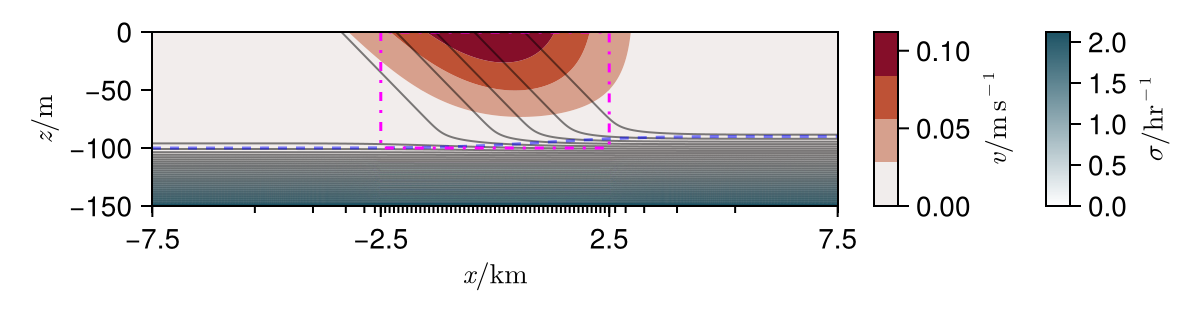

In [3]:
include("src-fig/figures/preinitial_conditions.jl")
include("src-simulation/parameters.jl")
fig = preinitial_conditions(sp)
save("figures/paper/preinitial.png", fig; px_per_unit=2)

fig

## Movies

801 / 801 


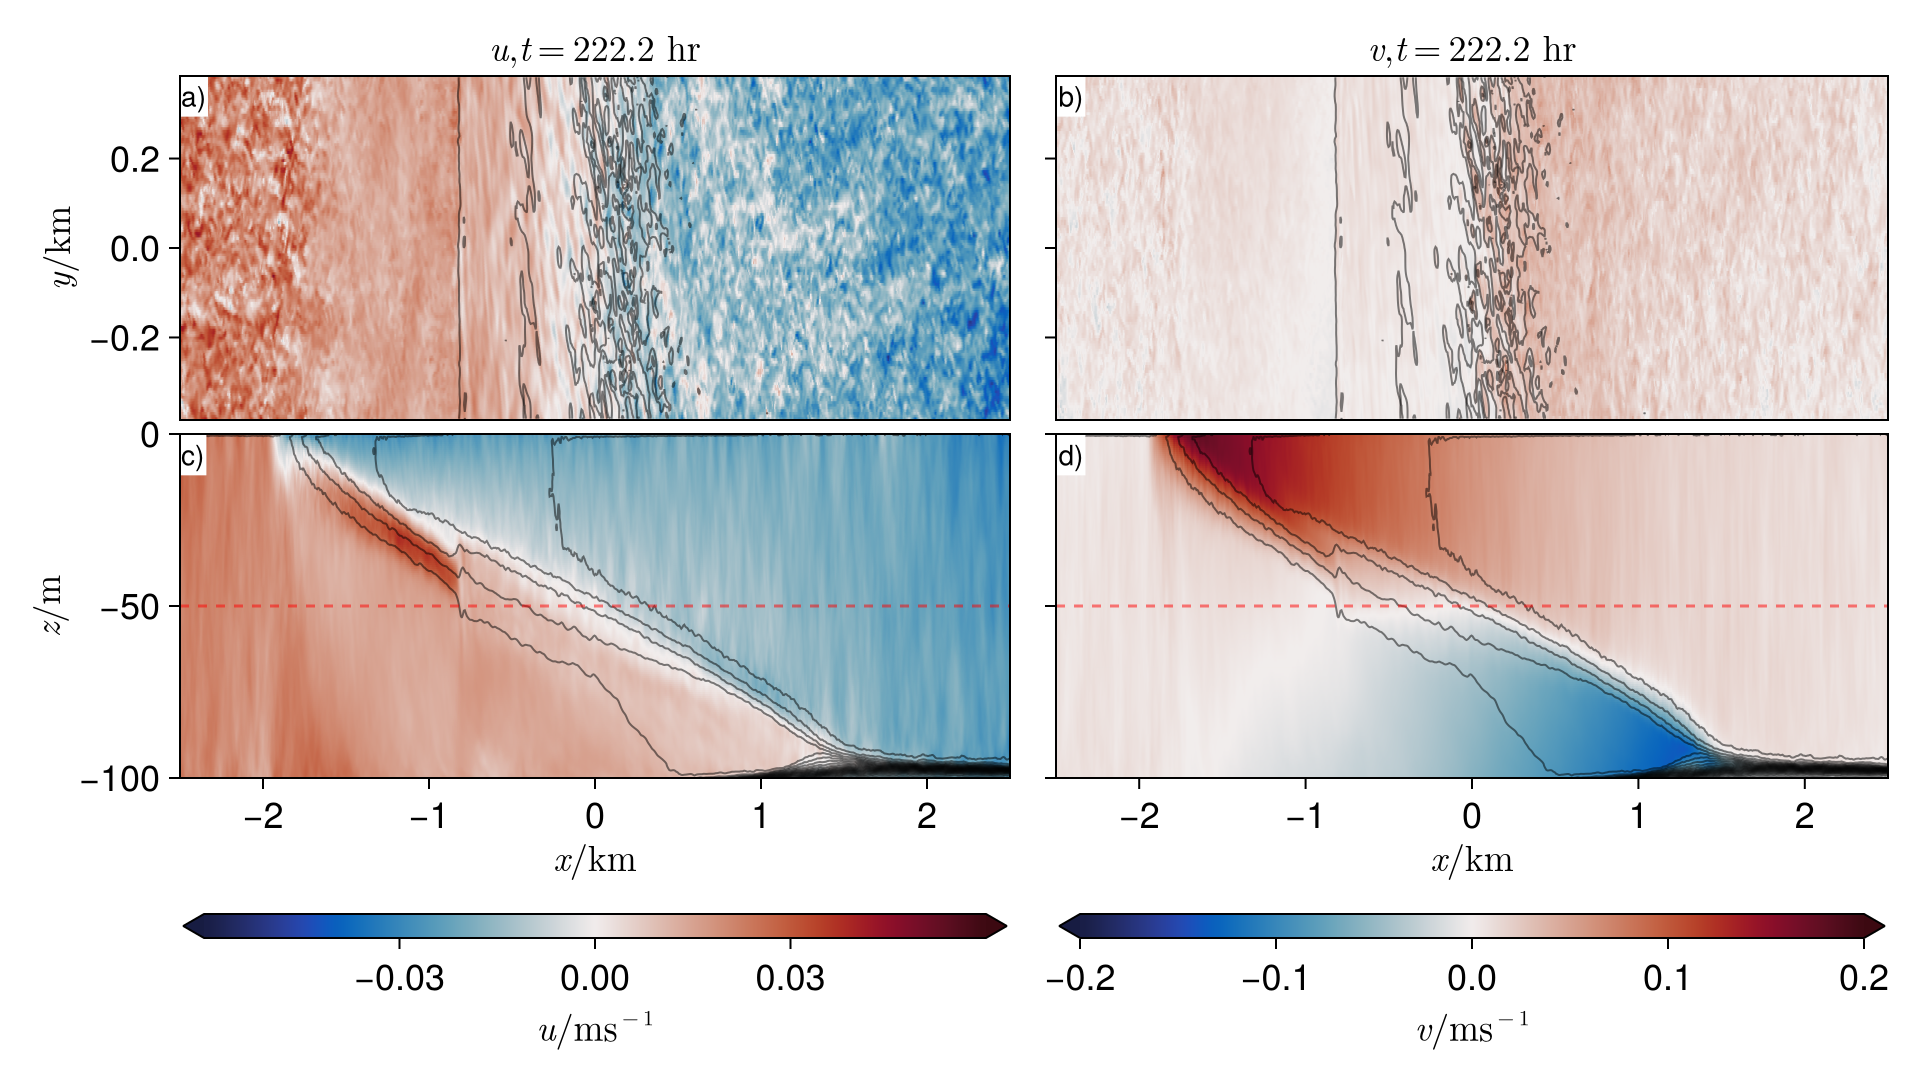

In [2]:
include("src-fig/video/uv_video.jl")

uv_video(foldername, "uv.mp4", 401:1201, -50; background=true, fig_kw=(; fontsize=18), record_kw=(; px_per_unit=2))

In [ ]:
include("src-fig/video/full_video.jl")

full_video(foldername, "full.mp4", 401:1201, -50; background=true, fig_kw=(; fontsize=18), record_kw=(; px_per_unit=2), ht_u_kw=(; highclip=nothing, lowclip=nothing))

36 / 801 

## Cartoon

## Hovmoller

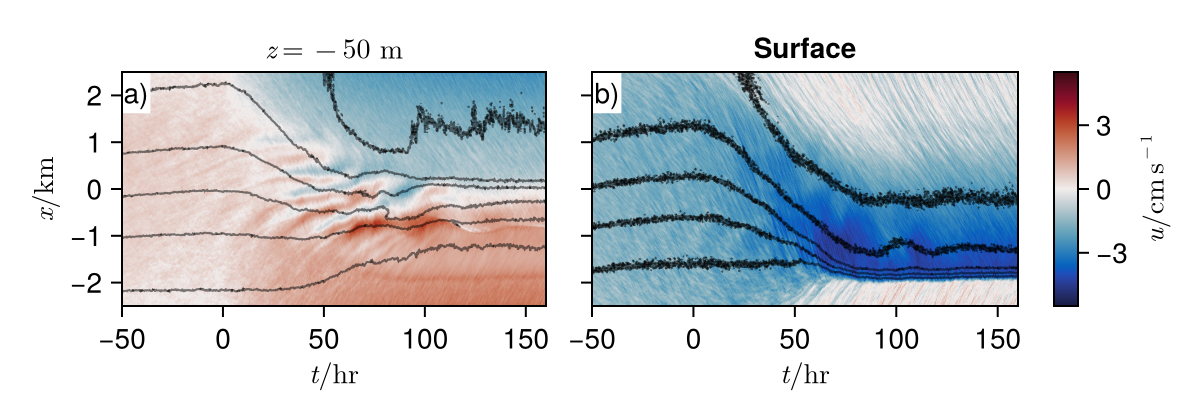

In [20]:
include("src-fig/figures/hovmoller.jl")

# Presentation
#fig = hovmoller(foldername, -50; ax_kw=(; limits=(0, 120, -2.5, 2.5)), ht_kw=(; colorrange=(-0.055, 0.055)), σ=0, fig_kw=(; size=(800, 320), fontsize=18), background=true)
#save("figures/presentation/hovmoller.png", fig; px_per_unit=2)
#save("figures/presentation/hovmoller.svg", fig)

# Paper
fig = hovmoller(foldername, -50; fig_kw=(; size=(600, 210)), ax_kw=(; limits=(-50, 160, -2.5, 2.5), xticks=[-50, 0, 50, 100, 150]), ht_kw=(; colorrange=(-5.5, 5.5)), σ=0, background=true)
save("figures/paper/hovmoller.png", fig; px_per_unit=2)
#save("figures/paper/hovmoller.svg", fig)

fig

## Across-front velocity

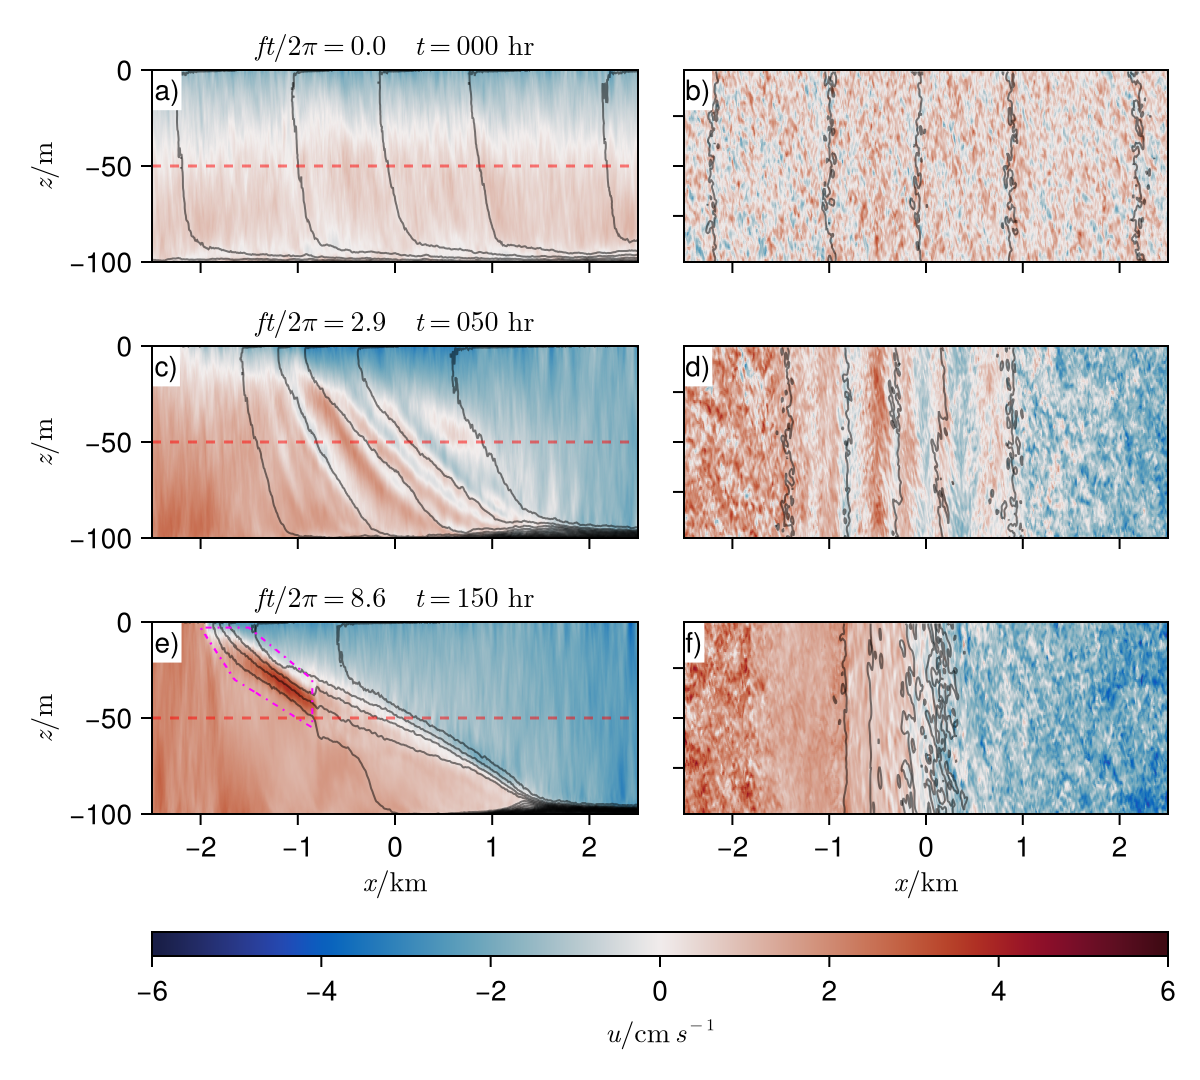

In [7]:
include("src-fig/figures/u_evolution.jl")
include("src-fig/figures/regions.jl")

# Presentation
#fig = u_evolution(foldername, frames, -50, regions.arrest; fig_kw=(; size=(800, 720), fontsize=18), background=true)
#save("figures/presentation/u-evolution.svg", fig)
#save("figures/presentation/u-evolution.png", fig; px_per_unit=2)

# Snapshots
for frame in frames
    fig = u_evolution(foldername, [frame], -50; fig_kw=(; size=(600, 270)), background=true)
    save("figures/presentation/snapshot_$frame.png", fig; px_per_unit=2)
end
# Paper
fig = u_evolution(foldername, frames, -50, regions.arrest; fig_kw=(; size=(600, 540)), background=true, ht_kw=(; colorrange=(-6, 6)))
#save("figures/paper/u-evolution.svg", fig)
save("figures/paper/u-evolution.png", fig; px_per_unit=2)

fig

## Turbulent kinetic energy

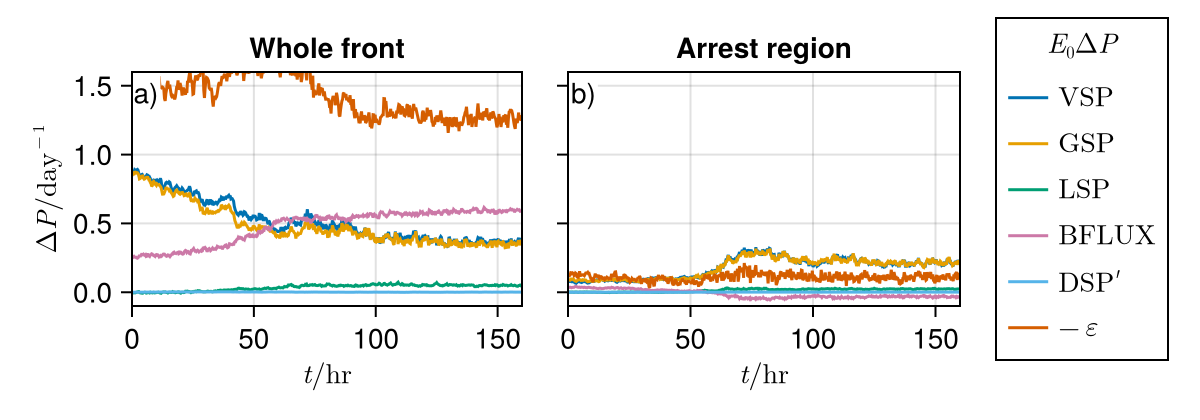

In [6]:
include("src-fig/figures/region_plots.jl")
include("src-fig/figures/regions.jl")

# Presentation
#fig = tke_by_region(foldername, []; ax_kw=(; limits=(0, 200, -1.3, 1.3)), fig_kw=(; fontsize=18))
#save("figures/presentation/tke.svg", fig)
#save("figures/presentation/tke.png", fig; px_per_unit=2)

# Paper
fig = tke_by_region(foldername, []; fig_kw=(; size=(600, 210)), ax_kw=(; xticks=[0, 50, 100, 150], limits=(0, 160, -0.1, 1.6)))
#save("figures/paper/tke.svg", fig)
#save("figures/paper/tke.png", fig; px_per_unit=2)

fig

## Potential vorticity

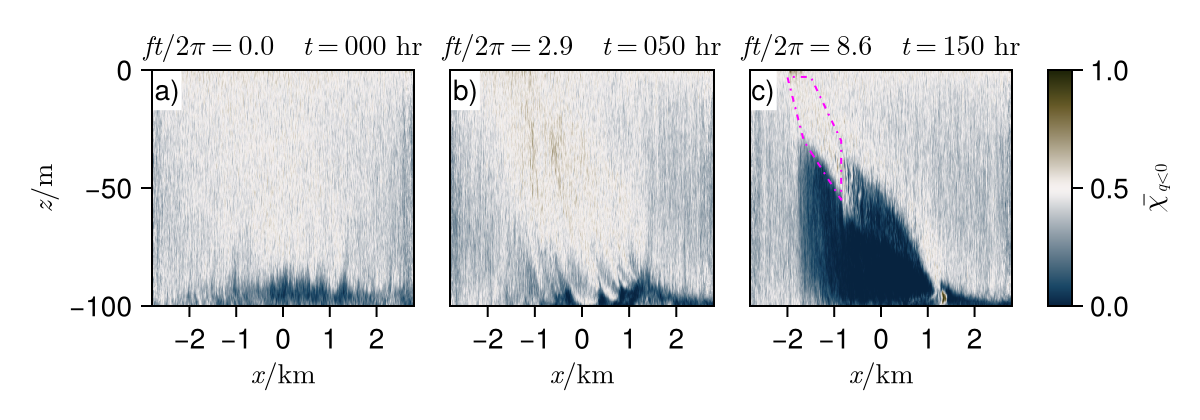

In [12]:
include("src-fig/figures/regions.jl")
include("src-fig/figures/pv_plot.jl")

# Presentation
fig = instability_plot(foldername, frames[end:end]; fig_kw=(; size=(400, 280)), ax_kw=(; xticks=-2:2, limits=(-2.8, 2.8, -100, 0)))
#save("figures/presentation/pv.svg", fig)
save("figures/presentation/pv.png", fig; px_per_unit=2)

# Paper
fig = instability_plot(foldername, frames, regions.arrest; fig_kw=(; size=(600, 210)), ax_kw=(; xticks=-2:2, limits=(-2.8, 2.8, -100, 0)))
#save("figures/paper/pv.svg", fig)
save("figures/paper/pv.png", fig; px_per_unit=2)

fig